<a href="https://colab.research.google.com/github/joshna-pinto/YuvaIntern-Week5-Deep-Learning-Titanic-Survival-Prediction/blob/main/YuvaIntern_Week5_Deep_Learning_Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Step 2: Load the Titanic dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Step 3: Basic dataset exploration

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin      

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Step 4: Select features and target

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features].copy()
y = df['Survived']

print("Features selected:")
print(X.head())

print("\nTarget variable:")
print(y.head())

Features selected:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target variable:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [5]:
# Step 5: Handle missing values

# Fill missing Age values with the median age
X['Age'] = X['Age'].fillna(X['Age'].median())

# Fill missing Embarked values with the most common value
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

print("Missing values after treatment:")
print(X.isnull().sum())

Missing values after treatment:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [6]:
# Step 6: Encode categorical variables

X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

print("Encoded dataset:")
print(X.head())

print("\nFeatures after encoding:")
print(X.columns.tolist())

Encoded dataset:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

Features after encoding:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [7]:
# Step 7: Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (712, 8)
Testing data shape: (179, 8)


In [8]:
# Step 8: Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)

Feature scaling completed!
Training data shape: (712, 8)


In [21]:
# Step 9: Build the neural network

from tensorflow.keras import Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

print("Neural network architecture:")
model.summary()

Neural network architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 10: Compile the neural network

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
# Step 11: Train the neural network

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training completed!")

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4692 - loss: 0.7618 - val_accuracy: 0.6224 - val_loss: 0.6874
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6063 - loss: 0.6862 - val_accuracy: 0.6713 - val_loss: 0.6428
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6766 - loss: 0.6170 - val_accuracy: 0.6993 - val_loss: 0.6068
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7206 - loss: 0.5876 - val_accuracy: 0.7343 - val_loss: 0.5710
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7381 - loss: 0.5678 - val_accuracy: 0.7622 - val_loss: 0.5415
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7364 - loss: 0.5390 - val_accuracy: 0.7622 - val_loss: 0.5173
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7750 - loss: 0.5168 - val_accuracy: 0.7902 - val_loss: 0.4963
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7873 - loss: 0.5057 - val_accuracy: 0.7972 - val_

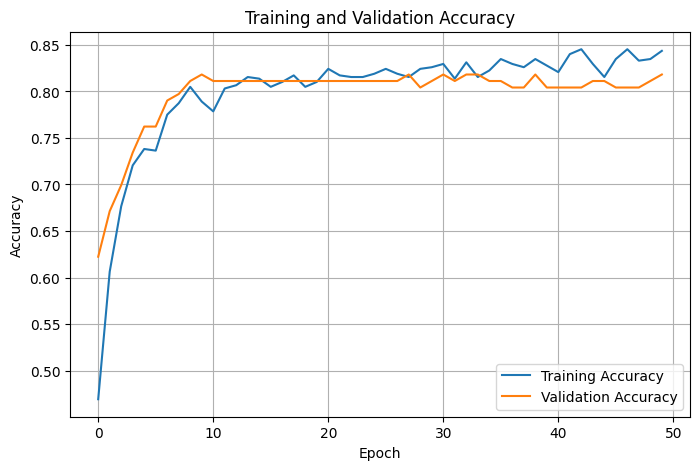

In [12]:
# Step 12: Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

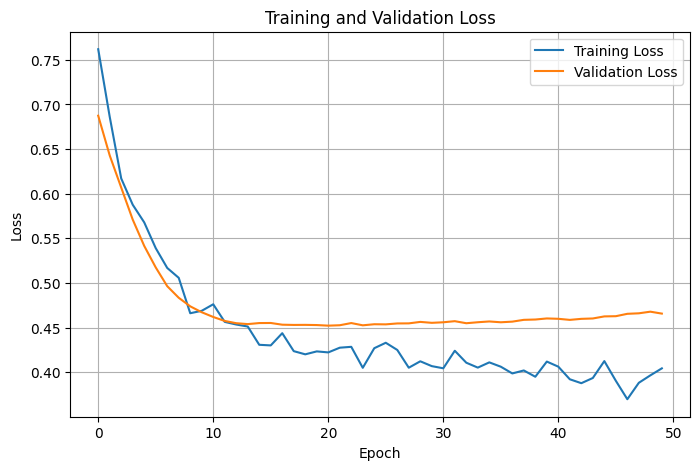

In [13]:
# Step 13: Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Step 14: Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4287422299385071
Test Accuracy: 0.8100558519363403


In [15]:
# Step 15: Generate predictions

y_probability = model.predict(X_test_scaled)

y_pred = (y_probability >= 0.5).astype(int).ravel()

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predictions generated successfully!

First 20 predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [16]:
# Step 16: Classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86       110
           1       0.89      0.58      0.70        69

    accuracy                           0.81       179
   macro avg       0.84      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



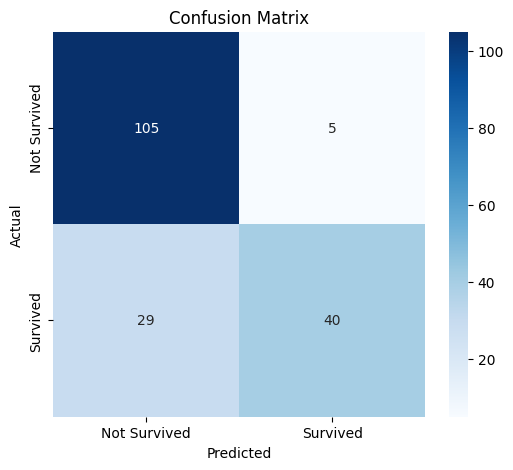

In [17]:
# Step 17: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [18]:
# Step 18: Calculate final accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Final Test Accuracy: 81.01%


In [19]:
# Step 19: Save the trained model

model.save("titanic_deep_learning_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [20]:
# Step 20: Project Summary

print("====================================")
print("DEEP LEARNING PROJECT SUMMARY")
print("====================================")

print("Dataset: Titanic Dataset")
print("Problem Type: Binary Classification")
print("Model: Artificial Neural Network")
print("Framework: TensorFlow / Keras")
print("Optimizer: Adam")
print("Activation Function: ReLU + Sigmoid")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("====================================")

DEEP LEARNING PROJECT SUMMARY
Dataset: Titanic Dataset
Problem Type: Binary Classification
Model: Artificial Neural Network
Framework: TensorFlow / Keras
Optimizer: Adam
Activation Function: ReLU + Sigmoid
Test Accuracy: 81.01%
